In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
import joblib


pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/processed/processed.csv")
df.head()

,std_byte_size,total_requests_above_p95,had_error,had_suspicious_ua,had_referrer_type_interno,had_referrer_type_api,had_referrer_type_nulo,had_bot_sessions,had_unknown_country,had_suspicious_post_usage,had_suspicious_high_freq_path,night_activity_rate
0,0.0,False,False,False,False,False,False,False,False,False,False,0.0
1,0.0,False,False,False,False,False,False,False,False,False,False,0.0
2,0.0,False,False,False,False,False,False,False,False,True,True,0.0
3,0.0,False,False,False,False,False,False,False,False,False,True,0.0
4,0.0,False,False,False,False,False,False,False,False,False,False,0.0


In [ ]:
X_scaled = StandardScaler().fit_transform(df)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

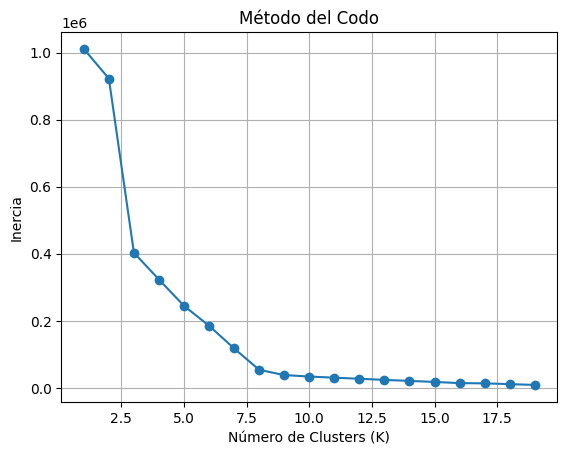

In [4]:

inertias = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()


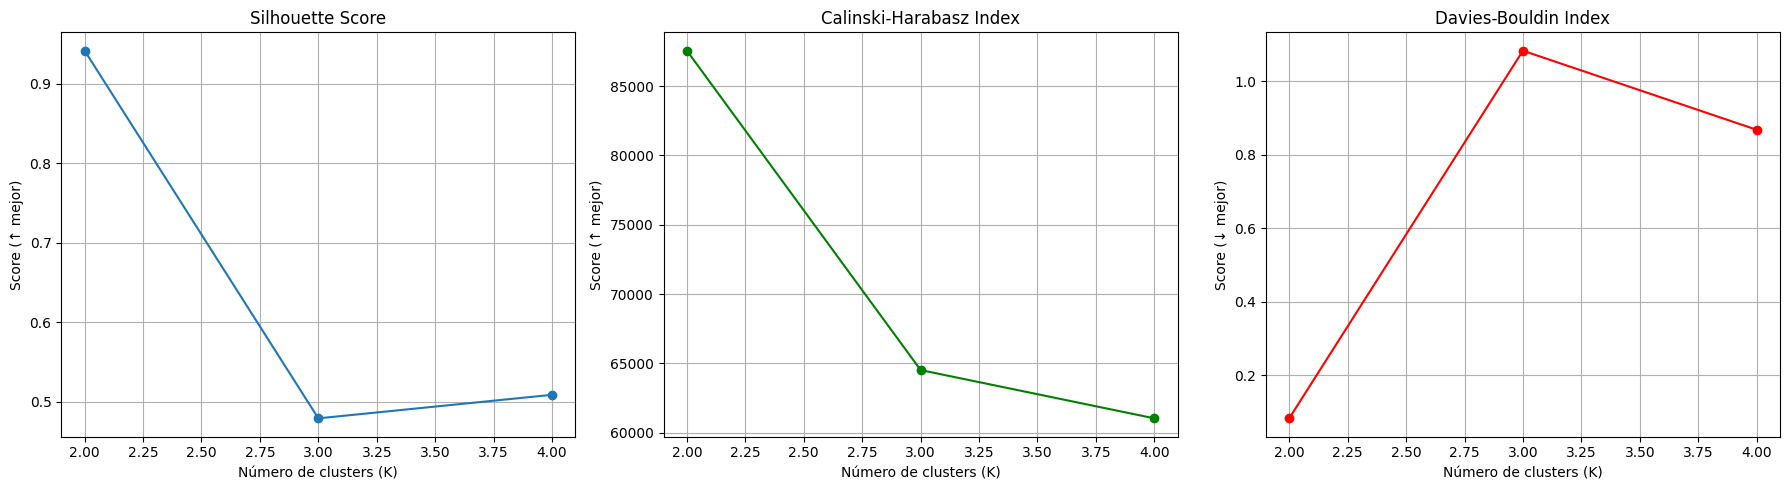

In [ ]:
# Rango de K a probar
K_range = range(2, 5)

# Almacenar resultados
silhouette_scores = []
ch_scores = []
db_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    silhouette_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Graficar todas juntas
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette
ax[0].plot(K_range, silhouette_scores, marker='o')
ax[0].set_title("Silhouette Score")
ax[0].set_xlabel("Número de clusters (K)")
ax[0].set_ylabel("Score (↑ mejor)")
ax[0].grid(True)

# Calinski-Harabasz
ax[1].plot(K_range, ch_scores, marker='o', color='green')
ax[1].set_title("Calinski-Harabasz Index")
ax[1].set_xlabel("Número de clusters (K)")
ax[1].set_ylabel("Score (↑ mejor)")
ax[1].grid(True)

# Davies-Bouldin
ax[2].plot(K_range, db_scores, marker='o', color='red')
ax[2].set_title("Davies-Bouldin Index")
ax[2].set_xlabel("Número de clusters (K)")
ax[2].set_ylabel("Score (↓ mejor)")
ax[2].grid(True)

plt.tight_layout()
plt.show()


| Criterio                  | ¿Qué evalúa?                                                       | ¿Qué buscamos?                          | Resultado con K=3                           | ¿Por qué importa?                                                                 |
|---------------------------|---------------------------------------------------------------------|------------------------------------------|---------------------------------------------|------------------------------------------------------------------------------------|
| Método del Codo           | Si agregar más grupos mejora realmente la agrupación               | Un punto de equilibrio ("codo")          | K=3 es donde la mejora se estabiliza         | Nos ayuda a elegir una cantidad adecuada de grupos sin hacer el modelo más complejo |
| Silhouette Score          | Qué tan bien separados y definidos están los grupos                | Valor alto (hasta 1)                     | K=3 da 0.60 (bueno)                          | Los grupos están bien diferenciados y tienen sentido                               |
| Índice Calinski-Harabasz | Qué tan distintos son los grupos entre sí                          | Valor alto                               | K=3 da un valor alto                         | Muestra que los grupos tienen buena separación estadística                         |
| Índice Davies-Bouldin     | Cuánto se parecen los grupos entre sí (menos es mejor)             | Valor bajo (cerca de 0)                  | K=3 da 0.44 (bajo)                           | Los grupos están bien separados, sin mezclarse                                     |


In [11]:
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Agrega etiquetas al DataFrame
df['cluster'] = clusters


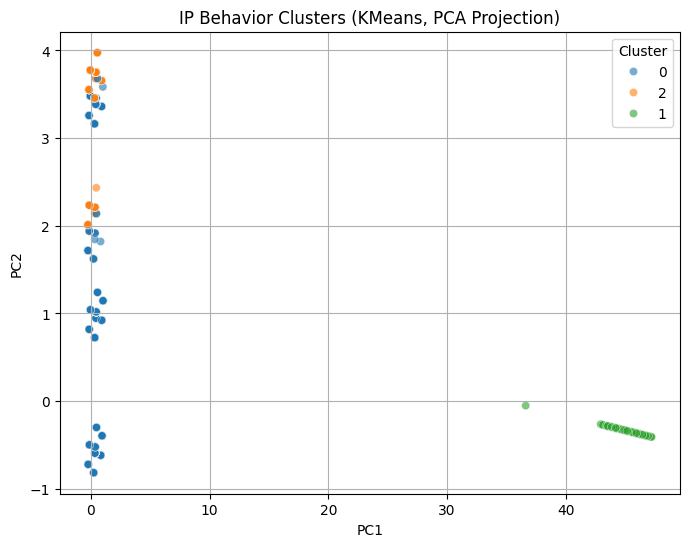

In [12]:
df_plot = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': clusters.astype(str)  # como string para mostrar categorías en la leyenda
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.6)
plt.title("IP Behavior Clusters (KMeans, PCA Projection)")
plt.grid(True)
plt.show()

In [13]:
df.groupby('cluster').mean()

,std_byte_size,total_requests_above_p95,had_error,had_suspicious_ua,had_referrer_type_interno,had_referrer_type_api,had_referrer_type_nulo,had_bot_sessions,had_unknown_country,had_suspicious_post_usage,had_suspicious_high_freq_path,night_activity_rate
cluster,,,,,,,,,,,,
0,0.000000,0.0,0.053418,0.0,0.0,0.025671,0.0,0.000000,0.0,0.041082,0.276624,0.242217
1,4988.348679,1.0,1.000000,1.0,0.0,0.000000,1.0,0.996047,1.0,1.000000,1.000000,0.997695
2,0.000000,0.0,0.047130,0.0,1.0,0.000000,0.0,0.000000,0.0,0.041865,0.957884,0.291301


| Cluster | Descripción General        | Comportamiento Destacado                                                                                  | Señales Sospechosas                         | Actividad Nocturna     | Posible Etiqueta     |
|---------|----------------------------|------------------------------------------------------------------------------------------------------------|---------------------------------------------|------------------------|----------------------|
| 0       | Tráfico humano típico      | Navegación variada. Referrer normal o desde API. Rutas visitadas diversas.                  | Ninguna. Sin errores, UA válido, IPs limpias. | Moderada (esperable)   | Humano               |
| 1       | Bot claro       | Accesos automáticos frecuentes. Navegación mecánica, desde IPs con país desconocido y UA sospechoso.       | Todas activadas: errores, bots, referrer nulo, scraping. | Muy alta (principalmente madrugada) | Bot                  |
| 2       | Tráfico humano enfocado    | Navegación centrada casi exclusivamente en `/item`, sin errores, desde referrers internos.                 | Ruta muy específica. Comportamiento uniforme. | Algo elevada           | Humano / Requiere revisión |


In [8]:
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)
print(f'Silhouette Score: {score:.4f}')

score_ch = calinski_harabasz_score(X_scaled, labels)
print(f'Calinski-Harabasz Index: {score_ch:.2f}')

score_db = davies_bouldin_score(X_scaled, labels)
print(f'Davies-Bouldin Index: {score_db:.4f}')

Silhouette Score (K=3): 0.6008
Calinski-Harabasz Index: 63509.35
Davies-Bouldin Index: 0.4485


In [ ]:
# Guardar el modelo entrenado
joblib.dump(kmeans, '../models/kmeans_model.pkl')

['../models/kmeans_model.pkl']